<a href="https://colab.research.google.com/github/nazpedawi/WebDevelopment1Project/blob/main/All_patient_Timeseries_classification_with_IMU_sensor_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data preperation
The data used for this model first needs to be constructed from our patient csv files `TABLE_ML_TOTAL_Patient001.csv` for the sensor data and `Clinical_Scores_TOTAL_median_001.csv` for the dystonia scores

# TODO
iterate of each patient to create a dataframe containing all measurements from all patients
tune the model
remove the 4.5 dystonia score instance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import keras_tuner
from tensorflow.keras import layers,models
print(tf.__version__)
print(tf.keras.__name__)



2.20.0
tensorflow.keras


In [ ]:
df = pd.read_csv('./drive/MyDrive/shared_drive/CSVs/timeseries_data.csv')
print(len(df))
print(df.columns)
x_labels = ['Acc_X', 'Acc_Y', 'Acc_Z', 'Acc_T', 'Euler_X', 'Euler_Y','Euler_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z', 'Gyr_T']
y_label = ['Dystonia_score']
df.head()

4876
Index(['Unnamed: 0', 'index', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Acc_T', 'Euler_X',
       'Euler_Y', 'Euler_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z', 'Gyr_T',
       'window_number_score', 'Dystonia_score', 'file_name_txt', 'Limb'],
      dtype='object')


,Unnamed: 0,index,Acc_X,Acc_Y,Acc_Z,Acc_T,Euler_X,Euler_Y,Euler_Z,Gyr_X,Gyr_Y,Gyr_Z,Gyr_T,window_number_score,Dystonia_score,file_name_txt,Limb
0,0,0,"[0.043161917, 0.022508314, 0.055145115, 0.0401...","[0.011610157, -0.0010590043, -0.046286628, 0.0...","[0.12179661, 0.112485886, 0.111076355, 0.08236...","[30.8589328540669, 30.8384755977226, 30.823590...","[-27.2683582305908, -27.2357120513916, -27.213...","[-13.5336465835571, -13.5474853515625, -13.554...","[5.05477857589722, 5.06884670257568, 5.0808653...","[3.64203071594238, 2.37911868095398, 1.7406325...","[-1.5060271024704, -1.00000941753387, -0.56989...","[-0.0574364885687828, 0.221517816185951, 0.308...","[0.129738818524648, 0.11472061819235, 0.132368...",1,0.0,Active_1163612410_2021-10-16T111539.578_video,right
1,1,1,"[0.0210262, 0.051702235, 0.03414205, 0.0363343...","[0.0024535018, -0.007115535, -0.015224585, 0.0...","[0.09120655, 0.106206894, 0.11735821, 0.109633...","[30.8644002551341, 30.8568040124721, 30.849930...","[-27.8939533233643, -27.880220413208, -27.8684...","[-12.3296537399292, -12.3387880325317, -12.345...","[4.74533557891846, 4.75289106369019, 4.7599067...","[1.09713923931122, 1.14417695999146, 1.0018856...","[-0.715772569179535, -0.563517808914185, -0.37...","[0.0753717720508575, 0.005372263956815, -0.024...","[0.0936309538583534, 0.118337045237147, 0.1231...",2,0.0,Active_1163612410_2021-10-16T111539.578_video,right
2,2,2,"[0.020310286, 0.04617476, 0.02903154, 0.024369...","[-0.014481852, -0.021626666, -0.0018833202, -0...","[0.14151764, 0.1369276, 0.12591267, 0.12085152...","[31.0735686709527, 31.0714763902357, 31.067853...","[-28.0917377471924, -28.0897922515869, -28.086...","[-12.3848276138306, -12.3855276107788, -12.385...","[4.79968595504761, 4.79571914672852, 4.7925848...","[0.236616507172585, 0.329628974199295, 0.42243...","[0.0832604840397835, 0.113765209913254, 0.1535...","[-0.223355546593666, -0.188278928399086, -0.22...","[0.143699249079184, 0.146112931614875, 0.12922...",3,0.0,Active_1163612410_2021-10-16T111539.578_video,right
3,3,3,"[0.039173886, 0.048242588, 0.057264242, 0.0710...","[-0.0011043776, 0.014832767, 0.013750517, -0.0...","[0.15386677, 0.12834167, 0.12610054, 0.0919675...","[31.2252984717845, 31.2132324382128, 31.205849...","[-28.3394966125488, -28.3219776153564, -28.311...","[-12.232346534729, -12.2411794662476, -12.2450...","[4.71825122833252, 4.72069787979126, 4.7259755...","[1.49957871437073, 1.31042885780334, 0.9372903...","[-0.387481719255447, -0.404949575662613, -0.22...","[-0.509884834289551, -0.239094540476799, 0.047...","[0.158779078925585, 0.137909182189595, 0.13917...",4,1.0,Active_1163612410_2021-10-16T111539.578_video,right
4,4,4,"[-1.1524581, -2.6704028, -0.26279134, 0.657611...","[-1.073978, 0.04641023, 0.50477225, 1.15997, 0...","[0.7575426, 0.5719843, 0.54023933, -1.3097696,...","[62.6252483463521, 63.2527799885861, 63.576079...","[-50.7092895507812, -51.7176361083984, -52.370...","[-23.6098365783691, -23.3637351989746, -23.159...","[-28.1614151000977, -27.934497833252, -27.6212...","[-78.7112197875977, -55.1400527954102, -31.802...","[8.43999671936035, 0.173111885786057, -5.38482...","[17.9113807678223, 18.7682800292969, 19.724241...","[1.7479871874686, 2.73136798383941, 0.78467371...",5,2.0,Active_1163612410_2021-10-16T111539.578_video,right


In [ ]:

data = df[x_labels + y_label]

data['Dystonia_score'].astype(float)
data.shape

(4876, 12)

In [ ]:
data[y_label].value_counts(dropna=False).sort_index()

,count
Dystonia_score,
0.0,678
1.0,1764
2.0,1764
3.0,642
4.0,28


In [ ]:
for i, (_, row) in enumerate(data.drop('Dystonia_score', axis=1).iterrows()):
    shapes = [np.array(v).shape for v in row.values]
    if len(set(shapes)) > 1:
        print(f"Row {i} has inconsistent shapes: {shapes}")
        break

In [ ]:
print(type(data.iloc[0, 0]))
print(data.iloc[0, 0])

<class 'str'>
[0.043161917, 0.022508314, 0.055145115, 0.040181596, 0.024455111, 0.018843707, 0.009277464, 0.0052176863, 0.012742809, 0.0077978084, -0.0015463744, 0.0013008454, 0.012465541, -0.0240472, 0.00035214465, 0.0038838729, -0.0077876383, 0.017289734, 0.028114466, 0.03869311, 0.05594071, 0.08459004, 0.024003727, 0.05468334, 0.014154741, 0.07330041, -0.040684834, 0.0047702133, 0.0073580467, 0.024837207, 0.031980906, 0.035241175, 0.054960158, 0.050015718, 0.024112578, 0.0075646844, -0.004591515, 0.0007020542, -0.011544892, 0.0034284652, 0.0020400027, 0.005545468, -0.00028386145, 0.020324145, 0.059527423, -0.018495921, -0.18117994, 0.38165587, -0.13953377, -0.095590346, 0.09598272, 0.30004022, 0.17904808, -0.17869928, -0.46440795, 0.0005693993, 0.25133094, 0.21786043, -0.028920341, -0.18650569, -0.22706704, -0.2982311, -0.37771958, -0.42750686, -0.23008837, 0.05343759, -0.15299943, 0.29892892, 0.43564585, 0.22316976, 0.2594554, 0.8032951, 0.2521596, -0.15616772, 0.2018264, 0.3979160

In [ ]:
import ast

def to_array(x):
    if isinstance(x, str):
        return np.array(ast.literal_eval(x))
    return np.array(x)

X_df = data.drop(y_label, axis=1).map(to_array)

In [ ]:
tensor_list = []

for i, (_, row) in enumerate(X_df.iterrows()):
    try:
        stacked = np.stack(row.values)
        tensor_list.append(stacked)
    except Exception as e:
        print(f"Row {i} failed: {e}")
        break

# Check shapes
print(set(t.shape for t in tensor_list))

tensor = np.array(tensor_list)
print(tensor.shape)

{(11, 300)}
(4876, 11, 300)


In [ ]:
from sklearn.model_selection import train_test_split
encoder = OneHotEncoder(sparse_output=False)
""" setting the data to
0 → No dystonia
1–2 → Moderate
3–4 → Severe
"""
y_df = data[['Dystonia_score']]
#y_df[y_df['Dystonia_score'] == 2 ] = 1
#y_df[y_df['Dystonia_score'] >= 3] =  2
y = encoder.fit_transform(y_df)

x = np.transpose(tensor, (0, 2, 1))
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=158)
print(f"x_train : {x_train.shape} {type(x_train)} \ny_train : {y_train.shape} {type(y_train)}")

x_train : (3266, 300, 11) <class 'numpy.ndarray'> 
y_train : (3266, 5) <class 'numpy.ndarray'>


In [ ]:


def build_model(hp):
    model = models.Sequential()

    # Tune the number of filters in the Conv1D layer
    model.add(layers.Conv1D(
        filters=hp.Int('conv_filters', min_value=32, max_value=128, step=32),
        kernel_size=hp.Choice('conv_kernel', values=[3, 5]),
        activation='relu',
        input_shape=(300, 11),
        strides=2
    ))

    model.add(layers.MaxPooling1D(2))

    # Tune the number of LSTM units
    model.add(layers.LSTM(
        units=hp.Int('lstm_units', min_value=50, max_value=150, step=50)
    ))

    # Tune the number of units in the Dense layer
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))

    model.add(layers.Dense(5, activation='softmax'))

    # Tune the learning rate
    learning_rate = hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')

    model.compile(optimizer='adam', loss='CategoricalCrossentropy',
    metrics=['accuracy'])

    return model

In [ ]:
tuner = keras_tuner.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Total number of different variations to try
    executions_per_trial=1, # How many times to train each variation (to average results)
    directory='my_tuning_dir',
    project_name='timeseries_cnn_tuning'
)

# Optional: Add an EarlyStopping callback to save time during trials
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

Reloading Tuner from my_tuning_dir/timeseries_cnn_tuning/tuner0.json


In [ ]:
tuner.search(
    x_train, y_train,
    epochs=6,
    validation_data=(x_test, y_test),
    callbacks=[stop_early]
)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The search is complete. The optimal number of LSTM units is {best_hps.get('lstm_units')}
and the optimal learning rate is {best_hps.get('lr')}.
""")

Trial 10 Complete [00h 02m 32s]
val_accuracy: 0.6018633246421814

Best val_accuracy So Far: 0.6857143044471741
Total elapsed time: 00h 34m 55s

The search is complete. The optimal number of LSTM units is 100 
and the optimal learning rate is 0.0019762634240727646.



In [ ]:
model = tuner.hypermodel.build(best_hps)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 149, 32)        │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 74, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        53,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,077 (238.58 KB)

 Trainable params: 61,077 (238.58 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

#model = models.Sequential([
#    layers.Conv1D(64, 3, activation='relu', input_shape=(300, 11),strides=3),
#    layers.MaxPooling1D(2),
#    layers.LSTM(100),
#    layers.Dense(64, activation='relu'),
#
#    layers.Dense(3, activation='softmax')
#])
#
#model.compile(optimizer='adam', loss='CategoricalCrossentropy',
#    metrics=['accuracy'])
#model.summary()

In [ ]:
history =model.fit(x_train,y_train,epochs=30+-, validation_split=0.33)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.8003 - loss: 0.5459 - val_accuracy: 0.6243 - val_loss: 0.9565
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.7870 - loss: 0.5492 - val_accuracy: 0.6095 - val_loss: 1.0121
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.7975 - loss: 0.5377 - val_accuracy: 0.6289 - val_loss: 1.0067
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.8108 - loss: 0.5068 - val_accuracy: 0.6503 - val_loss: 0.9753
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.8218 - loss: 0.5030 - val_accuracy: 0.6447 - val_loss: 0.9962
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.8163 - loss: 0.4865 - val_accuracy: 0.6317 - val_loss: 1.0204
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8144 - loss: 0.4735 - val_accuracy: 0.6299 - val_loss: 1.0672
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.8218 - loss: 0.4617 - val_accuracy: 0.6178 

In [ ]:
y_pred = model.predict(x_test)


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


              precision    recall  f1-score   support

           0       0.63      0.65      0.64       215
           1       0.69      0.74      0.71       582
           2       0.67      0.67      0.67       600
           3       0.64      0.49      0.56       200
           4       0.25      0.08      0.12        13

    accuracy                           0.67      1610
   macro avg       0.57      0.53      0.54      1610
weighted avg       0.66      0.67      0.66      1610

Cohen-K: 0.5152488590288524


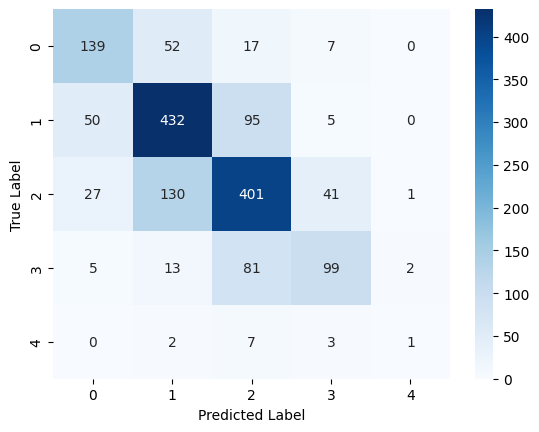

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns

y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)


print(classification_report(y_test_classes, y_pred_classes))

#are these the right values?
print(f'Cohen-K: {cohen_kappa_score(y_test_classes, y_pred_classes)}')

cm = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

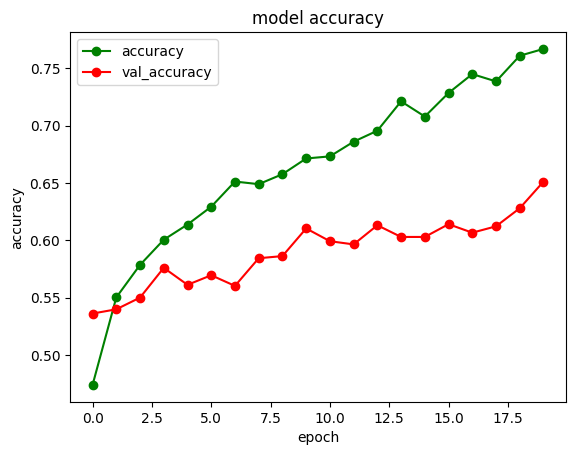

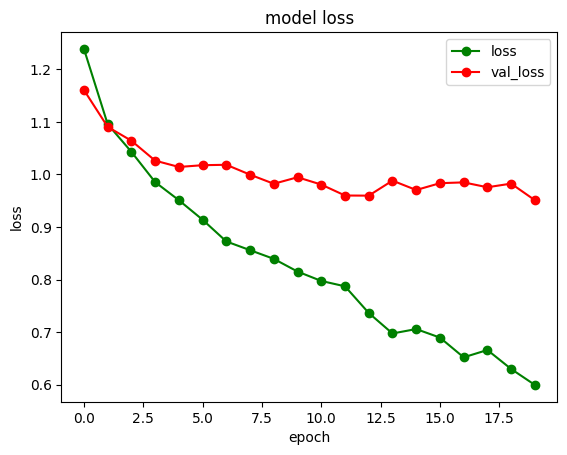

In [ ]:
# summarize history for accuracy
plt.plot(history.history['accuracy'],color='green', marker='o')
plt.plot(history.history['val_accuracy'],color='red', marker='o')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy', 'val_accuracy'])
plt.show()

# summarize history for loss
plt.plot(history.history['loss'], color='green', marker='o')
plt.plot(history.history['val_loss'], color='red', marker='o')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'])
plt.show()

